In [ ]:
!pip install gradio opencv-python keras tensorflow

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

import gradio as gr
import cv2

c:\Users\josse\OneDrive\Documents\GitHub\neural-network-from-scratch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
(X_train_raw, Y_train_raw), (X_test_raw, Y_test_raw) = mnist.load_data()

print (f"Shape of X_train_raw : {X_train_raw.shape}")
print (f"Shape of Y_train_raw : {Y_train_raw.shape}")
print("-"*50)
print (f"Shape of X_test_raw : {X_test_raw.shape}")
print (f"Shape of Y_test_raw : {Y_test_raw.shape}")

Shape of X_train_raw : (60000, 28, 28)
Shape of Y_train_raw : (60000,)
--------------------------------------------------
Shape of X_test_raw : (10000, 28, 28)
Shape of Y_test_raw : (10000,)


In [3]:
# Flatten & Normalize
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1).T / 255
X_test = X_test_raw.reshape(X_test_raw.shape[0], -1).T / 255

Y_train = Y_train_raw
Y_test = Y_test_raw

m_train = X_train[1]
print(f"New shape of X_train : {X_train.shape}")
print(f"New shape of X_test : {X_test.shape}")
print("-"*50)
print("784 = 28*28 pixels")

New shape of X_train : (784, 60000)
New shape of X_test : (784, 10000)
--------------------------------------------------
784 = 28*28 pixels


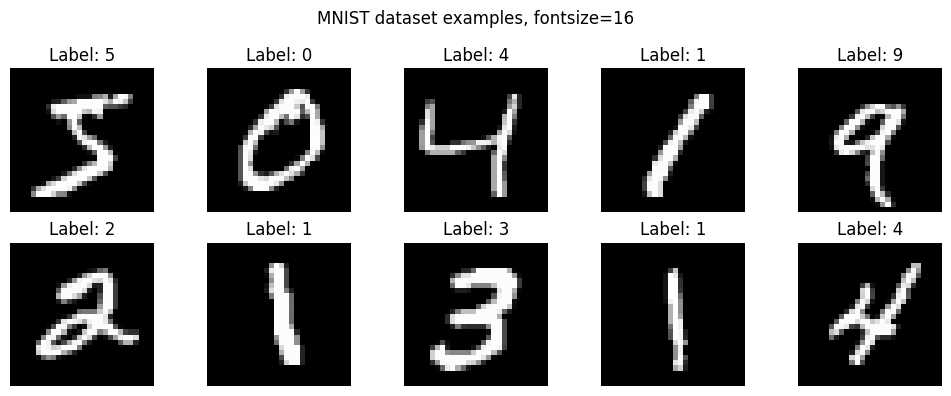

In [4]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[:, i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {Y_train[i]}")
    plt.axis("off")
    
plt.suptitle("MNIST dataset examples, fontsize=16")
plt.tight_layout()
plt.show()

In [5]:
n_neurons = 64
temperature = 1

In [6]:
def init_param():
    W1 = np.random.randn(n_neurons, 784) * np.sqrt(2./784)
    b1 = np.zeros((n_neurons, 1))
    W2 = np.random.randn(10, n_neurons) * np.sqrt(2./n_neurons)
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

In [7]:
def ReLU(z):
    return np.maximum(z, 0)

def softmax(z):
    A = np.exp((z - np.max(z, axis=0)) / temperature) / sum((np.exp(z - np.max(z, axis=0))) / temperature)
    return A

In [8]:
def ReLU_deriv(z):
    return z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, 10)) 
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y.T

In [9]:
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    
    return Z1, A1, Z2, A2

In [10]:
def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

In [11]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [12]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

In [13]:
def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_param()
    history_accuracy = []
    
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        
        if i % 10 == 0:
            predictions = get_predictions(A2)
            acc = get_accuracy(predictions, Y)
            history_accuracy.append(acc)
            if i % 50 == 0:
                print(f"Iteration: {i} | Accuracy: {acc*100:.2f}%")
                
    return W1, b1, W2, b2, history_accuracy

In [14]:
W1, b1, W2, b2, history = gradient_descent(X_train, Y_train, alpha=0.15, iterations=101)

Iteration: 0 | Accuracy: 6.09%
Iteration: 50 | Accuracy: 86.96%
Iteration: 100 | Accuracy: 89.28%


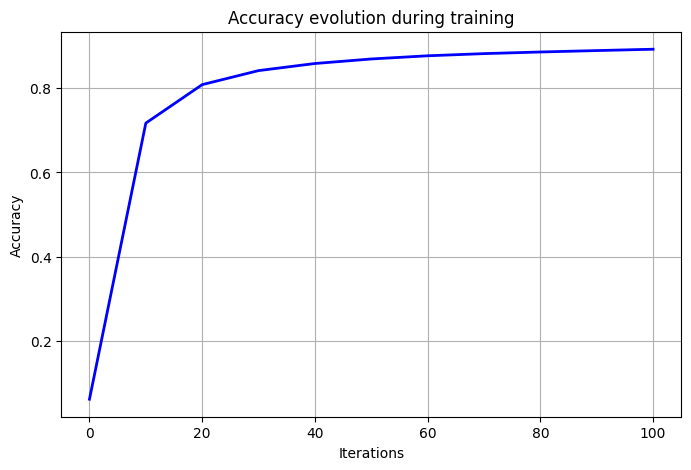

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(range(0, 101, 10), history, color='b', linewidth=2)
plt.title('Accuracy evolution during training')
plt.xlabel('Iterations')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [16]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

test_predictions = make_predictions(X_test, W1, b1, W2, b2)
test_acc = get_accuracy(test_predictions, Y_test)
print(f"Accuracy on TEST set: {test_acc*100:.2f}%")

Accuracy on TEST set: 89.74%


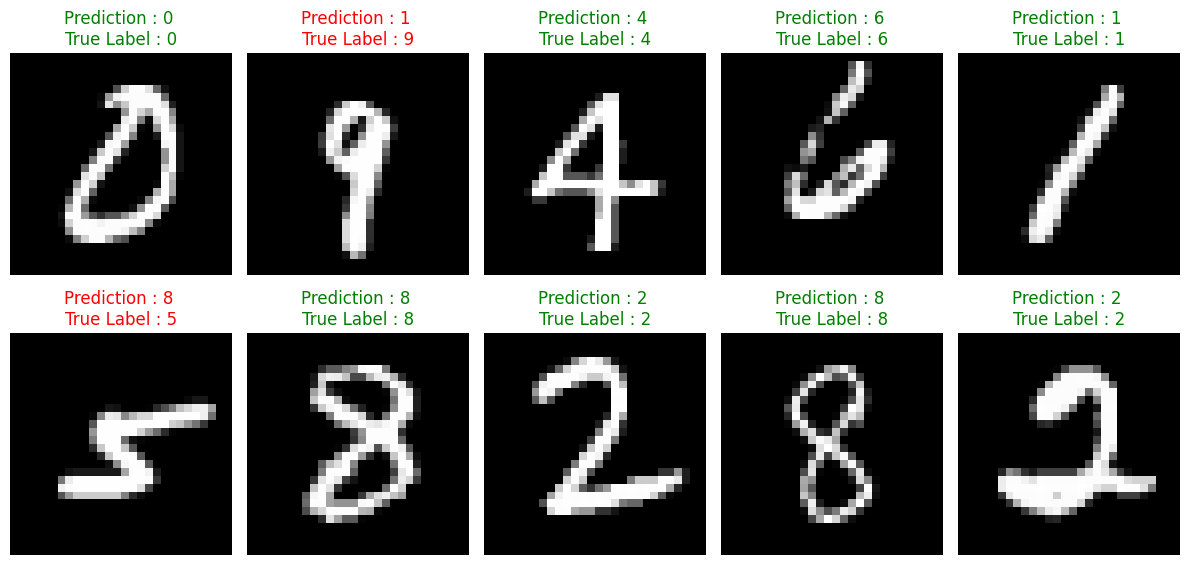

In [20]:
def test_prediction_visuel(index, W1, b1, W2, b2):
    current_image = X_test[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2)[0]
    label = Y_test[index]
    
    plt.imshow(current_image.reshape((28, 28)), cmap='gray')
    color = 'green' if prediction == label else 'red'
    plt.title(f"Prediction : {prediction} \nTrue Label : {label}", color=color)
    plt.axis('off')
    
plt.figure(figsize=(12, 6))
random_indices = np.random.choice(X_test.shape[1], 10, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    test_prediction_visuel(idx, W1, b1, W2, b2)

plt.tight_layout()
plt.show()

In [21]:
def predict_drawing(img):
    if img is None:
        return "Draw a number"
    
    if isinstance(img, dict):
        img = img['composite'] 
    
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
    img = 255 - img
        
    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    img_normalized = img_resized / 255.0
    img_flattened = img_normalized.reshape(784, 1)
    prediction = make_predictions(img_flattened, W1, b1, W2, b2)[0]
    
    return f"Prediction : {prediction}"

In [22]:
interface = gr.Interface(
    fn=predict_drawing,
    inputs=gr.Sketchpad(type="numpy",
                        image_mode="L",
                        label="Draw here",
                        interactive=True,
                        layers=False
                        ), 
    outputs=gr.Label(label="Model prediction"),
    title="NN from scratch",
    description="Draw a number between 0 and 9 and hit Submit"
)

In [23]:
interface.launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [24]:
def interactive_step(img, true_label_str):
    global W1, b1, W2, b2 

    if img is None:
        return "Draw a number !", None, "Waiting..."

    if isinstance(img, dict):
        img = img['composite']
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
    img = 255 - img
        
    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    X_input = (img_resized / 255.0).reshape(784, 1)

    Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_input)
    prediction = int(np.argmax(A2, axis=0)[0])

    fig = plt.figure(figsize=(10, 4))

    # Left : probabilities
    plt.subplot(1, 2, 1)
    plt.bar(range(10), A2.flatten(), color='skyblue', edgecolor='black')
    plt.xticks(range(10))
    plt.ylim(0, 1)
    plt.title("Output Probabilities")
    plt.xlabel("Digit")
    plt.ylabel("Confidence")

    # Right : activation of hidden layer
    plt.subplot(1, 2, 2)
    plt.imshow(A1.reshape(8, 8), cmap='magma') 
    plt.title("Activation of Hidden Layer Neurons")
    plt.colorbar(label='Activation level (ReLU)')
    plt.axis('off')

    plt.tight_layout()

    status = "Test mode only. No learning triggered."
    
    if true_label_str and true_label_str.strip() != "":
        try:
            Y_true = np.array([int(true_label_str)])
            alpha_interact = 0.05 
            
            dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X_input, Y_true)
            W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha_interact)
            
            status = f"Back propagation done for {Y_true[0]}."
        except ValueError:
            status = "Invalid label. Please enter a digit from 0 to 9."

    return f"Prediction : {prediction}", fig, status

In [25]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Visualization and Interactive Learning")
    gr.Markdown("Draw, observe the neurons activate, and correct the model if it's wrong!")
    
    with gr.Row():
        with gr.Column():
            sketch = gr.Sketchpad(
                type="numpy",
                image_mode="L",
                label="Drawing Area",
                interactive=True,
                layers=False
            )
            true_label = gr.Textbox(
                label="True digit (Optional: Leave empty to just test, fill in to correct the model)"
            )
            btn = gr.Button("Predict & Learn", variant="primary")
            
        with gr.Column():
            pred_text = gr.Textbox(label="Model result", text_align="center")
            status_text = gr.Textbox(label="Learning Status")
            plot_output = gr.Plot(label="Model Neuron Activity")

    btn.click(
        fn=interactive_step, 
        inputs=[sketch, true_label], 
        outputs=[pred_text, plot_output, status_text]
    )

demo.launch(inbrowser=True)

C:\Users\josse\AppData\Local\Temp\ipykernel_20028\2099477332.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Exception in callback _ProactorBasePipeTransport._call_connection_lost(None)
handle: <Handle _ProactorBasePipeTransport._call_connection_lost(None)>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\proactor_events.py", line 165, in _call_connection_lost
    self._sock.shutdown(socket.SHUT_RDWR)
ConnectionResetError: [WinError 10054] Une connexion existante a dû être fermée par l’hôte distant


In [26]:
def interactive_step_detailed(img, true_label_str):
    global W1, b1, W2, b2 

    if img is None:
        return "Draw a digit!", None

    if isinstance(img, dict):
        img = img['composite']
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
    img = 255 - img 
        
    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    X_input = (img_resized / 255.0).reshape(784, 1)

    Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_input)
    prediction = int(np.argmax(A2, axis=0)[0])

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    
    axes[0, 0].imshow(img_resized, cmap='gray')
    axes[0, 0].set_title("1. Input (X)")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(A1.reshape(8, 8), cmap='magma')
    axes[0, 1].set_title("2. Hidden Neurons (A1)\n(What the network 'sees')")
    axes[0, 1].axis('off')

    axes[0, 2].bar(range(10), Z2.flatten(), color='orange')
    axes[0, 2].set_title("3. Raw Output (Z2)\n(Pre-Softmax)")
    axes[0, 2].set_xticks(range(10))

    axes[0, 3].bar(range(10), A2.flatten(), color='skyblue')
    axes[0, 3].set_title("4. Probabilities (A2)\n(Before Backprop)")
    axes[0, 3].set_xticks(range(10))
    axes[0, 3].set_ylim(0, 1)

    status = f"Prediction: {prediction} | Waiting for correction..."
    
    for j in range(4):
        axes[1, j].axis('off')

    if true_label_str and true_label_str.strip() != "":
        try:
            Y_true = np.array([int(true_label_str)])
            
            one_hot_Y = np.zeros((1, 10)) 
            one_hot_Y[0, Y_true[0]] = 1
            one_hot_Y = one_hot_Y.T
            
            dZ2 = A2 - one_hot_Y
            dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
            
            alpha_interactive = 0.05
            dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X_input, Y_true)
            W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha_interactive)

            # Forward pass again to get new prediction distribution
            _, _, _, A2_new = forward_prop(W1, b1, W2, b2, X_input)
            
            axes[1, 3].axis('on')
            axes[1, 3].bar(range(10), A2_new.flatten(), color='blue')
            axes[1, 3].set_title("5. Probabilities (A2)\n(After Backprop)")
            axes[1, 3].set_xticks(range(10))
            axes[1, 3].set_ylim(0, 1)

            axes[1, 2].axis('on')
            axes[1, 2].bar(range(10), dZ2.flatten(), color='red')
            axes[1, 2].set_title("6. Output Error (dZ2)\n(What to correct)")
            axes[1, 2].set_xticks(range(10))

            axes[1, 1].axis('on')
            axes[1, 1].imshow(dZ1.reshape(8, 8), cmap='coolwarm')
            axes[1, 1].set_title("7. Neuron Blame (dZ1)\n(Red = decrease, Blue = increase)")
            
            axes[1, 0].axis('on')
            update_intensity = np.mean(np.abs(dW1), axis=1).reshape(8, 8)
            axes[1, 0].imshow(update_intensity, cmap='Greens')
            axes[1, 0].set_title("8. Weight Updates (dW1)\n(Which connections change)")

            status = f"Learning: The model adjusted its weights for the digit {Y_true[0]}!"
        except ValueError:
            status = "Invalid label. Enter a digit from 0 to 9."

    plt.tight_layout()
    return status, fig

In [27]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Neural Network X-Ray")
    gr.Markdown("Draw a digit, watch the neurons activate, and correct the model if it's wrong to trigger Backpropagation!")
    
    with gr.Row():
        with gr.Column(scale=1):
            sketch = gr.Sketchpad(type="numpy", label="Draw here")
            true_label = gr.Textbox(label="True digit (Triggers Backpropagation)")
            btn = gr.Button("Run Propagation (Forward & Backward)", variant="primary")
            status_text = gr.Textbox(label="Status")
            
        with gr.Column(scale=3):
            plot_output = gr.Plot(label="Data Flow")

    btn.click(
        fn=interactive_step_detailed, 
        inputs=[sketch, true_label], 
        outputs=[status_text, plot_output]
    )

demo.launch(inbrowser=True)

C:\Users\josse\AppData\Local\Temp\ipykernel_20028\4063677120.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
